Loading dataset...
--- Basic Exploration ---
Shape: (2000, 17)

Data Types:
 customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly

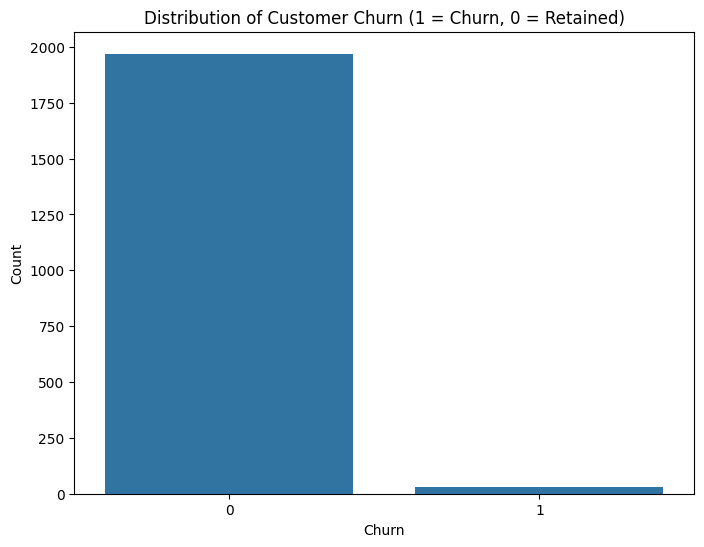

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os

# ==========================================
# Task 1: Dataset Understanding
# ==========================================
print("Loading dataset...")
df = pd.read_csv(r'C:\Users\Lenovo\Downloads\ai_project_synthetic_datasets-20260514T180014Z-3-001\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv')

print("--- Basic Exploration ---")
print(f"Shape: {df.shape}")
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

# Target variable distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Customer Churn (1 = Churn, 0 = Retained)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [13]:
# ==========================================
# Task 2: Data Preprocessing
# ==========================================
print("\nStarting Data Preprocessing...")

# 1. Handling missing values
# Drop customer_id as it has no predictive value
df = df.drop(columns=['customer_id'])

# Separate features (X) and target (y)
X = df.drop(columns=['churn'])
y = df['churn']

# 2.Encode Categorical Columns
# This converts columns like 'region' into multiple 0/1 columns (e.g., region_North, region_South)
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.Scaling or normalizing numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing complete. Input feature shape: {X_train_scaled.shape[1]} features.")


Starting Data Preprocessing...
Preprocessing complete. Input feature shape: 24 features.


In [14]:
# ==========================================
# Task 3: Neural Network Model Building
# ==========================================
print("\n--- Task 3: Building Baseline Neural Network ---")

def build_model(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),  # Hidden Layer with ReLU
        Dense(1, activation='sigmoid')                          # Output Layer for binary classification
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_model(X_train_scaled.shape[1])
baseline_model.summary()


--- Task 3: Building Baseline Neural Network ---


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)


--- Task 4: Training and Evaluating Baseline Model ---
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9475 - loss: 0.1637 - val_accuracy: 0.9825 - val_loss: 0.0806
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9850 - loss: 0.0648 - val_accuracy: 0.9825 - val_loss: 0.0794
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0560 - val_accuracy: 0.9825 - val_loss: 0.0725
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9856 - loss: 0.0495 - val_accuracy: 0.9825 - val_loss: 0.0731
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9875 - loss: 0.0424 - val_accuracy: 0.9825 - val_loss: 0.0763
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9856 - loss: 0.0397 - val_accuracy: 0.9775 - val_loss: 0.0837
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9869 - loss: 0.0357 - val_accuracy: 0.9825 - val_loss: 0.0737
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

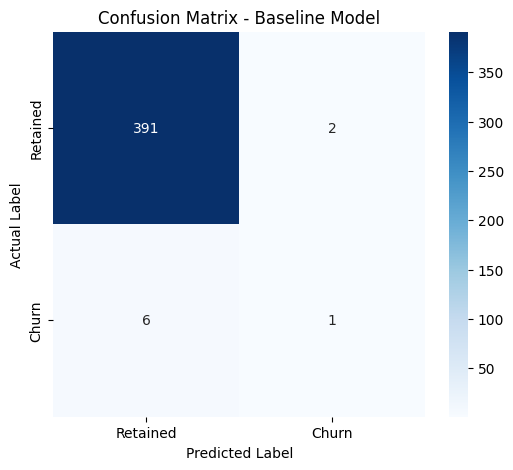

In [15]:
# ==========================================
# Task 4: Training and Evaluation
# ==========================================
from sklearn.metrics import accuracy_score


print("\n--- Task 4: Training and Evaluating Baseline Model ---")

history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Predict classes
y_pred_probs = baseline_model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

# Evaluation Metrics
print("\n--- Baseline Evaluation Results ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churn'], yticklabels=['Retained', 'Churn'])
plt.title('Confusion Matrix - Baseline Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('results/evaluation_outputs.png')  # Required file path
plt.show()

In [16]:
# ==========================================
# Task 5: Hyperparameter Experimentation
# ==========================================
print("\n--- Task 5: Running Hyperparameter Experiments ---")

# Defining 3 distinct configurations to analyze behavior
experiments = [
    {
        "name": "Exp_1_Deep_Network",
        "layers": [64, 32], 
        "lr": 0.005, 
        "batch_size": 32, 
        "epochs": 20, 
        "activation": "relu"
    },
    {
        "name": "Exp_2_High_Learning_Rate",
        "layers": [32], 
        "lr": 0.5,  # Deliberately high to showcase unstable updates
        "batch_size": 32, 
        "epochs": 20, 
        "activation": "relu"
    },
    {
        "name": "Exp_3_Tanh_Small_Batch",
        "layers": [32], 
        "lr": 0.001, 
        "batch_size": 16, 
        "epochs": 20, 
        "activation": "tanh"
    }
]

experiment_results = []

for exp in experiments:
    print(f"Running Experiment: {exp['name']}...")
    
    # Construct dynamic sequential model
    model = Sequential()
    model.add(Dense(exp['layers'][0], activation=exp['activation'], input_shape=(X_train_scaled.shape[1],)))
    
    # Add optional extra layers
    for units in exp['layers'][1:]:
        model.add(Dense(units, activation=exp['activation']))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=Adam(learning_rate=exp['lr']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Fit model silently
    exp_history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=exp['epochs'],
        batch_size=exp['batch_size'],
        verbose=0
    )
    
    # Log final training performance
    experiment_results.append({
        "Experiment Name": exp['name'],
        "Hidden Architecture": f"Layers: {exp['layers']}",
        "Activation": exp['activation'],
        "Learning Rate": exp['lr'],
        "Batch Size": exp['batch_size'],
        "Final Train Accuracy": round(exp_history.history['accuracy'][-1], 4),
        "Final Test Accuracy": round(exp_history.history['val_accuracy'][-1], 4)
    })

# Structure the performance table
comparison_df = pd.DataFrame(experiment_results)

# Save table as a CSV in the results directory
comparison_df.to_csv('results/model_comparison_table.csv', index=False)

print("\n--- Final Model Comparison Table ---")
print(comparison_df.to_string(index=False))


--- Task 5: Running Hyperparameter Experiments ---
Running Experiment: Exp_1_Deep_Network...


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Experiment: Exp_2_High_Learning_Rate...
Running Experiment: Exp_3_Tanh_Small_Batch...

--- Final Model Comparison Table ---
         Experiment Name Hidden Architecture Activation  Learning Rate  Batch Size  Final Train Accuracy  Final Test Accuracy
      Exp_1_Deep_Network    Layers: [64, 32]       relu          0.005          32                 1.000               0.9825
Exp_2_High_Learning_Rate        Layers: [32]       relu          0.500          32                 0.985               0.9825
  Exp_3_Tanh_Small_Batch        Layers: [32]       tanh          0.001          16                 0.985               0.9825
